Cluster analysis - participants are categorized into groups based on marketing segmentation method:

- Geographic (not utilized since our research scope is limited to Australia)

- Demographic - Gender, Education, Income

- Behavrioral - Frequency of social media usage, social importance, number of social influencers followed

- Psychological - Stay up-to-date, Openness of experience, Socialability (Extraversion)

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Social Influencer Dataset.csv',header=1)

In [3]:
df.head()

,RQ1,RQ2,RQ3,RQ4,RQ5,RQ6,RQ7,RQ8,RQ9,RQ10,...,RQ52,RQ53,RQ54,RQ55,RQ56,RQ57,RQ58,RQ59,RQ60,RQ61
0,5.0,"Yes, I follow a lot (more than 25)",2,5,1,2,1,5.0,2,1.0,...,18-24,Male,High school graduate,Yes,Unemployed looking for work,"Less than $10,000",4.6,2.50,3.50,4.00
1,2.0,"Yes, I follow a few (less than 5)",4,4,4,4,3,4.0,4,5.0,...,18-24,Male,Bachelor's degree,Yes,Other,"Less than $10,000",4.6,4.25,3.75,4.00
2,4.0,"Yes, I follow a lot (more than 25)",3,3,3,3,3,3.0,4,1.0,...,24-34,Male,Bachelor's degree,Yes,Employed full time,"$10,000 - $29,999",3.6,3.50,3.25,3.75
3,4.0,"Yes, I follow a lot (more than 25)",3,2,2,4,2,2.0,3,3.0,...,18-24,Male,Bachelor's degree,Yes,Other,"Less than $10,000",4.2,3.50,4.00,3.50
4,4.0,"Yes, I follow a lot (more than 25)",3,4,2,3,2,4.0,3,1.0,...,18-24,Female,Associate's degree or Diploma,Yes,Employed part time,"Less than $10,000",2.4,2.75,3.00,1.00


Preprocessing of Demo data

In [ ]:
df_cluster=pd.DataFrame()

df_cluster['Demo_Gender'] = df['RQ53']
df_cluster['Demo_Education'] = df['RQ54']
df_cluster['Demo_Income'] = df['RQ57']

print(df_cluster['Demo_Education'].value_counts())
print(df_cluster['Demo_Gender'].value_counts())
print(df_cluster['Demo_Income'].value_counts())

Demo_Education
Bachelor's degree                49
High school graduate             29
Master's degree                  12
Associate's degree or Diploma     8
Professional degree               2
Name: count, dtype: int64
Demo_Gender
Female    58
Male      41
Name: count, dtype: int64
Demo_Income
Less than $10,000      46
$10,000 - $29,999      20
$50,000 - $79,999      12
$30,000 - $49,999      10
$100,000 - $149,999     4
$80,000 - $99,999       3
More than $150,000      2
Name: count, dtype: int64


Split point development:

Education: 0 = Below Bachelors, 1 = Bachelors and above

Gender: 0 = Female, 1 = Male

Income: 0 = Lower than $10,000, 1 = above $10,000

In [8]:
df_cluster['Demo_Education']=df_cluster['Demo_Education'].replace(
    {
        "High school graduate":0,
        "Associate's degree or Diploma":0,
        "Professional degree":0,
        "Bachelor's degree":1,
        "Master's degree":1
    }
)

df_cluster['Demo_Gender'] = df_cluster['Demo_Gender'].replace({
    'Female': 0,
    'Male': 1
})

df_cluster['Demo_Income'] = df_cluster['Demo_Income'].replace({
    'Less than $10,000': 0,
    '$10,000 - $29,999': 1,
    '$30,000 - $49,999': 1,
    '$50,000 - $79,999': 1,
    '$80,000 - $99,999': 1,
    '$100,000 - $149,999': 1,
    'More than $150,000': 1,
})

C:\Users\lilai\AppData\Local\Temp\ipykernel_20696\759114607.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cluster['Demo_Education']=df_cluster['Demo_Education'].replace(
C:\Users\lilai\AppData\Local\Temp\ipykernel_20696\759114607.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cluster['Demo_Gender'] = df_cluster['Demo_Gender'].replace({
C:\Users\lilai\AppData\Local\Temp\ipykernel_20696\759114607.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain

Preprocessing of behavioral data

In [27]:
df_cluster['Beha_Social_importance'] = df['RQ1'].astype('Int64')
df_cluster['Beha_Influence_follow'] = df['RQ2']
df_cluster['Beha_Frequency_1'] = df['RQ4'].astype('Int64')
df_cluster['Beha_Frequency_2'] = df['RQ5'].astype('Int64')
df_cluster['Beha_Frequency_3'] = df['RQ6'].astype('Int64')
df_cluster['Beha_Frequency_4'] = df['RQ7'].astype('Int64')

print(df_cluster['Beha_Influence_follow'].value_counts())


Beha_Influence_follow
Yes, I follow a lot (more than 25)     36
Yes, I follow a many (between 5-24)    36
Yes, I follow a few (less than 5)      23
No                                      5
Name: count, dtype: int64


In [28]:
#Reverse coding for Frequency_4
df_cluster['Beha_Frequency_4'] = df_cluster['Beha_Frequency_4'].replace({
    1:5,
    2:4,
    3:3,
    4:2,
    5:1
})

In [ ]:
print('the splitting point for influencer followed is: follows more than 25 = 1, follows less than 25 = 0')

df_cluster['Beha_Influence_follow'] = df_cluster['Beha_Influence_follow'].replace(
    {
        'Yes, I follow a lot (more than 25)':1,
        'Yes, I follow a many (between 5-24)':0,
        'Yes, I follow a few (less than 5)':0,
        'No':0
    }
)

df_cluster['Beha_Influence_follow']=df_cluster['Beha_Influence_follow'].astype('Int64')

the splitting point for influencer followed is: follows more than 25 = 1, follows less than 25 = 0


C:\Users\lilai\AppData\Local\Temp\ipykernel_20696\147496018.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cluster['Beha_Influence_follow'] = df_cluster['Beha_Influence_follow'].replace(


In [31]:
df_cluster['Psyc_Updated_1'] = df['RQ33'].astype('Int64')
df_cluster['Psyc_Updated_2'] = df['RQ34'].astype('Int64')
df_cluster['Psyc_Updated_3'] = df['RQ35'].astype('Int64')

df_cluster['Psyc_Openness_1'] = df['RQ36'].astype('Int64')
df_cluster['Psyc_Openness_2'] = df['RQ37'].astype('Int64')
df_cluster['Psyc_Openness_3'] = df['RQ38'].astype('Int64')
df_cluster['Psyc_Openness_4'] = df['RQ39'].astype('Int64')

df_cluster['Psyc_Extraversion_1'] = df['RQ40'].astype('Int64')
df_cluster['Psyc_Extraversion_2'] = df['RQ41'].astype('Int64')
df_cluster['Psyc_Extraversion_3'] = df['RQ42'].astype('Int64')
df_cluster['Psyc_Extraversion_4'] = df['RQ43'].astype('Int64')

In [44]:
df_cluster.isnull().sum()
df_cluster.dropna(inplace=True)
df_cluster['Demo_Education'] = df_cluster['Demo_Education'].astype('Int64')
df_cluster['Demo_Income'] = df_cluster['Demo_Income'].astype('Int64')
df_cluster['Demo_Gender'] = df_cluster['Demo_Gender'].astype('Int64')
df_cluster['Beha_Social_importance'] = df_cluster['Beha_Social_importance'].astype('Int64')
df_cluster['Beha_Frequency_1'] = df_cluster['Beha_Frequency_1'].astype('Int64')
df_cluster['Beha_Frequency_2'] = df_cluster['Beha_Frequency_2'].astype('Int64')
df_cluster['Beha_Frequency_3'] = df_cluster['Beha_Frequency_3'].astype('Int64')
df_cluster['Beha_Frequency_4'] = df_cluster['Beha_Frequency_4'].astype('Int64')

Reliability check for compound traits: Frequency, Updated, Openness, Extraversion

In [38]:
import pingouin as pg

#Frequency
Frequency = df_cluster[['Beha_Frequency_1','Beha_Frequency_2','Beha_Frequency_3','Beha_Frequency_4']]

alpha_frequency = pg.cronbach_alpha(Frequency)

print('alpha frequency:', alpha_frequency)

#Updated
Updated = df_cluster[['Psyc_Updated_1','Psyc_Updated_2','Psyc_Updated_3']]
alpha_updated = pg.cronbach_alpha(Updated)
print('alpha updated:', alpha_updated)

#Openness
Openness = df_cluster[['Psyc_Openness_1','Psyc_Openness_2','Psyc_Openness_3','Psyc_Openness_4']]
alpha_openness = pg.cronbach_alpha(Openness)
print('alpha openness:', alpha_openness)

#Extraversion
Extraversion = df_cluster[['Psyc_Extraversion_1','Psyc_Extraversion_2','Psyc_Extraversion_3','Psyc_Extraversion_4']]
alpha_extraversion = pg.cronbach_alpha(Extraversion)
print('alpha extraversion:', alpha_extraversion)


alpha frequency: (np.float64(0.6266036950581763), array([0.487, 0.736]))
alpha updated: (np.float64(0.880946872198282), array([0.832, 0.917]))
alpha openness: (np.float64(0.7667526671780209), array([0.679, 0.835]))
alpha extraversion: (np.float64(0.49878807347487086), array([0.311, 0.645]))


In [42]:
#alpha if item deleted

alpha_item_1_deleted_extraversion = df_cluster[['Psyc_Extraversion_2','Psyc_Extraversion_3','Psyc_Extraversion_4']]
alpha_item_2_deleted_extraversion = df_cluster[['Psyc_Extraversion_1','Psyc_Extraversion_3','Psyc_Extraversion_4']]
alpha_item_3_deleted_extraversion = df_cluster[['Psyc_Extraversion_1','Psyc_Extraversion_2','Psyc_Extraversion_4']]
alpha_item_4_deleted_extraversion = df_cluster[['Psyc_Extraversion_1','Psyc_Extraversion_2','Psyc_Extraversion_3']]

print('alpha if item 1 deleted extraversion:', pg.cronbach_alpha(alpha_item_1_deleted_extraversion))
print('alpha if item 2 deleted extraversion:', pg.cronbach_alpha(alpha_item_2_deleted_extraversion))    
print('alpha if item 3 deleted extraversion:', pg.cronbach_alpha(alpha_item_3_deleted_extraversion))
print('alpha if item 4 deleted extraversion:', pg.cronbach_alpha(alpha_item_4_deleted_extraversion))

alpha if item 1 deleted extraversion: (np.float64(0.43936085331541613), array([0.211, 0.61 ]))
alpha if item 2 deleted extraversion: (np.float64(0.40724123539232066), array([0.166, 0.587]))
alpha if item 3 deleted extraversion: (np.float64(0.33085904480135275), array([0.059, 0.534]))
alpha if item 4 deleted extraversion: (np.float64(0.5145792057886125), array([0.317, 0.662]))


after examining item 4 for psyc_extraversion, it indeedly looks like the item is not very correlated with the other items. therefore, this item will be removed from the dataset.

In [ ]:
df_cluster.drop(columns='Psyc_Extraversion_4',inplace=True)

In [53]:
df_cluster['Beha_Frequency'] = df_cluster[['Beha_Frequency_1','Beha_Frequency_2','Beha_Frequency_3','Beha_Frequency_4']].mean(axis=1).astype(int)

df_cluster['Psyc_Updated'] = df_cluster[['Psyc_Updated_1','Psyc_Updated_2', 'Psyc_Updated_3']].mean(axis=1).astype(int)

df_cluster['Psyc_Openness'] = df_cluster[['Psyc_Openness_1','Psyc_Openness_2','Psyc_Openness_3','Psyc_Openness_4']].mean(axis=1).astype(int)

df_cluster['Psyc_Extraversion'] = df_cluster[['Psyc_Extraversion_1','Psyc_Extraversion_2','Psyc_Extraversion_3']].mean(axis=1).astype(int)

In [55]:
df_clustering = pd.DataFrame()

df_clustering['Demo1'] = df_cluster['Demo_Gender']
df_clustering['Demo2'] = df_cluster['Demo_Education']
df_clustering['Demo3'] = df_cluster['Demo_Income']
df_clustering['Behaviour1'] = df_cluster['Beha_Social_importance']
df_clustering['Behaviour2'] = df_cluster['Beha_Influence_follow']
df_clustering['Behaviour3'] = df_cluster['Beha_Frequency']
df_clustering['Psych1'] = df_cluster['Psyc_Updated']
df_clustering['Psych2'] = df_cluster['Psyc_Openness']
df_clustering['Psych3'] = df_cluster['Psyc_Extraversion']

df_clustering.head()

,Demo1,Demo2,Demo3,Behaviour1,Behaviour2,Behaviour3,Psych1,Psych2,Psych3
0,1,0,0,5,1,3,5,3,3
1,1,1,0,2,0,3,4,3,4
2,1,1,1,4,1,3,2,3,3
3,1,1,0,4,1,3,4,5,3
4,0,0,0,4,1,3,3,2,1


以下是聚类分析

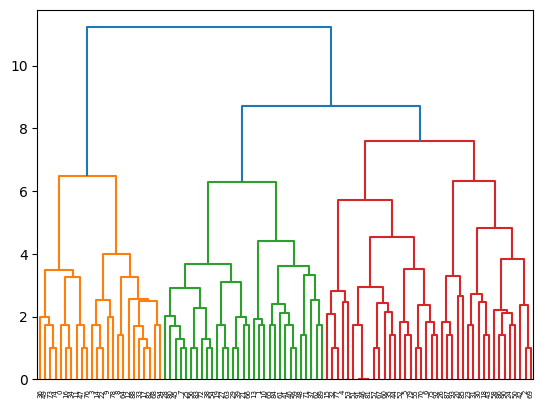

In [56]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib import pyplot as plt

links = linkage(df_clustering, 'ward')
dendro = dendrogram(links)

通过 dendrogram，确定 n_clusters = 4. 

In [57]:
clusters = fcluster(links, 4, 'maxclust')
df_clustering['label'] = clusters

至此，通过将参与者分为4个簇的聚类分析已经完成。接下来对各个簇进行解读。

解读分为以下几个步骤：

1.统计每个簇的人数
2.统计每个簇的属性值（连续变量：均值；分类变量：众数）
3.将属性值进行排序
4.将属性值进行可视化

In [60]:
df_clustering['label'].value_counts()

label
2    31
1    24
3    22
4    18
Name: count, dtype: int64

In [77]:
df_cluster_1 = pd.DataFrame()
df_cluster_2 = pd.DataFrame()
df_cluster_3 = pd.DataFrame()
df_cluster_4 = pd.DataFrame()

df_cluster_1 = df_clustering[df_clustering['label']==1]
df_cluster_2 = df_clustering[df_clustering['label']==2]
df_cluster_3 = df_clustering[df_clustering['label']==3]
df_cluster_4 = df_clustering[df_clustering['label']==4]

df_cluster_1_continuous = pd.DataFrame()
df_cluster_1_classification = pd.DataFrame()
df_cluster_2_continuous = pd.DataFrame()
df_cluster_2_classification = pd.DataFrame()
df_cluster_3_continuous = pd.DataFrame()
df_cluster_3_classification = pd.DataFrame()
df_cluster_4_continuous = pd.DataFrame()
df_cluster_4_classification = pd.DataFrame()

df_cluster_1_continuous = df_cluster_1[['Behaviour1', 'Behaviour3', 'Psych1', 'Psych2', 'Psych3']]
df_cluster_1_classification = df_cluster_1[['Demo1', 'Demo2', 'Demo3', 'Behaviour2']]

df_cluster_2_continuous = df_cluster_2[['Behaviour1', 'Behaviour3', 'Psych1', 'Psych2', 'Psych3']]  
df_cluster_2_classification = df_cluster_2[['Demo1', 'Demo2', 'Demo3', 'Behaviour2']]

df_cluster_3_continuous = df_cluster_3[['Behaviour1', 'Behaviour3', 'Psych1', 'Psych2', 'Psych3']]
df_cluster_3_classification = df_cluster_3[['Demo1', 'Demo2', 'Demo3', 'Behaviour2']]

df_cluster_4_continuous = df_cluster_4[['Behaviour1', 'Behaviour3', 'Psych1', 'Psych2', 'Psych3']]
df_cluster_4_classification = df_cluster_4[['Demo1', 'Demo2', 'Demo3', 'Behaviour2']]

In [75]:
df_cluster_2.head()

,Demo1,Demo2,Demo3,Behaviour1,Behaviour2,Behaviour3,Psych1,Psych2,Psych3,label
1,1,1,0,2,0,3,4,3,4,2
7,0,1,0,3,0,3,4,4,3,2
10,1,0,0,2,0,3,3,3,3,2
14,1,1,0,2,1,3,3,4,4,2
20,0,1,1,4,1,3,3,3,4,2


In [84]:
print('Cluster 1 Continuous Variables Description:')
print(df_cluster_1_continuous.describe())
print('Cluster 1 Classification Variables Description:')
print(df_cluster_1_classification.mode())

Cluster 1 Continuous Variables Description:
       Behaviour1  Behaviour3     Psych1     Psych2     Psych3
count        24.0   24.000000  24.000000  24.000000  24.000000
mean     4.458333    2.958333   4.375000   4.291667   3.166667
std      0.508977    0.806450   0.710939   0.624094   0.637022
min           4.0    2.000000   3.000000   3.000000   2.000000
25%           4.0    2.000000   4.000000   4.000000   3.000000
50%           4.0    3.000000   4.500000   4.000000   3.000000
75%           5.0    4.000000   5.000000   5.000000   4.000000
max           5.0    4.000000   5.000000   5.000000   4.000000
Cluster 1 Classification Variables Description:
   Demo1  Demo2  Demo3  Behaviour2
0      1      1      0           1


Cluster 1: <热爱网络>

基本信息：
性别：男 | 教育程度：本科及以上 | 收入：1w以下

行为：
社交非常重要 | 关注较多网红 | 社交媒体频率适中

心理：
喜欢保持更新 | 喜欢接受新事物 | 外向社交程度适中


In [85]:
print('Cluster 2 Continuous Variables Description:')
print(df_cluster_2_continuous.describe())
print('Cluster 2 Classification Variables Description:')
print(df_cluster_2_classification.mode())

Cluster 2 Continuous Variables Description:
       Behaviour1  Behaviour3     Psych1     Psych2     Psych3
count        31.0   31.000000  31.000000  31.000000  31.000000
mean     3.064516    2.516129   3.645161   3.741935   3.161290
std      0.813858    0.724383   0.608188   0.514311   0.582911
min           2.0    1.000000   2.000000   3.000000   2.000000
25%           2.0    2.000000   3.000000   3.000000   3.000000
50%           3.0    3.000000   4.000000   4.000000   3.000000
75%           4.0    3.000000   4.000000   4.000000   3.500000
max           4.0    3.000000   5.000000   5.000000   4.000000
Cluster 2 Classification Variables Description:
   Demo1  Demo2  Demo3  Behaviour2
0      0      0      1           0


Cluster 2: <专注于现实>

基本信息：
性别：女 | 教育程度：不到本科 | 收入：1w以下

行为：
社交重要适中 | 关注较少网红 | 社交媒体频率偏低

心理：
中等偏上保持更新 | 中等偏上接受新事物 | 外向社交程度适中

In [86]:
print('Cluster 3 Continuous Variables Description:')
print(df_cluster_3_continuous.describe())
print('Cluster 3 Classification Variables Description:')
print(df_cluster_3_classification.mode())

Cluster 3 Continuous Variables Description:
       Behaviour1  Behaviour3     Psych1     Psych2     Psych3
count        22.0   22.000000  22.000000  22.000000  22.000000
mean     3.636364    2.409091   3.500000   3.636364   1.818182
std      0.902138    0.503236   0.597614   0.726731   0.394771
min           2.0    2.000000   2.000000   2.000000   1.000000
25%           3.0    2.000000   3.000000   3.000000   2.000000
50%           4.0    2.000000   4.000000   4.000000   2.000000
75%           4.0    3.000000   4.000000   4.000000   2.000000
max           5.0    3.000000   4.000000   5.000000   2.000000
Cluster 3 Classification Variables Description:
   Demo1  Demo2  Demo3  Behaviour2
0      0      1      0           0


Cluster 3: <对网络无感>

基本信息：
性别：女 | 教育程度：本科及以上 | 收入：1w以下

行为：
社交重要适中偏上 | 关注较少网红 | 社交媒体频率较低

心理：
中等偏上保持更新 | 中等偏上接受新事物 | 外向社交程度非常低

In [87]:
print('Cluster 4 Continuous Variables Description:')
print(df_cluster_4_continuous.describe())
print('Cluster 4 Classification Variables Description:')
print(df_cluster_4_classification.mode())

Cluster 4 Continuous Variables Description:
       Behaviour1  Behaviour3     Psych1     Psych2     Psych3
count        18.0   18.000000  18.000000  18.000000  18.000000
mean     3.722222    2.833333   2.111111   3.555556   2.666667
std      0.826442    0.985184   0.832352   0.704792   0.594089
min           2.0    1.000000   1.000000   2.000000   2.000000
25%          3.25    2.000000   2.000000   3.000000   2.000000
50%           4.0    3.000000   2.000000   4.000000   3.000000
75%           4.0    3.000000   2.750000   4.000000   3.000000
max           5.0    5.000000   4.000000   4.000000   4.000000
Cluster 4 Classification Variables Description:
   Demo1  Demo2  Demo3  Behaviour2
0      1      1      1           0


Cluster 4: <富有的稳定型>

基本信息：
性别：男 | 教育程度：本科及以上 | 收入：1w及以上

行为：
社交重要适中偏上 | 关注较少网红 | 社交媒体频率较低

心理：
不爱保持更新 | 接受新事物适中 | 外向社交程度较低

该研究将问卷参与人群的数据进行聚类，并查看不同类别的问卷参与人群的差异，实施用户分层。

1. 先对数据进行了处理，包括处理缺失值，数据类型，数据转换等操作。

2. 对符合变量进行信度检验，确保了数据结构的稳定。

3. 使用scipy.cluster.hierarcy 库的 linkage/dendrogram/fcluster 函数对样本进行聚类。
- 先用linkage对数据进行聚类(wards方法：最小方差法)。
- 再用dendrogram对聚类结果进行可视化。
- 在确定好了分类数量后，用fcluster对数据分类（maxclust方法：最大），生成簇标签。

4. 对各簇进行描述分析，解读用户画像。